# Lab 3: Mine Crafting


As with previous labs, be sure to submit only the `lab3.ipynb` and `lab3.html` version of the lab in your github `Lab3` folder. No more, and no less.

## Introduction

Imagine you are a scientist for a mining company that operates a vertical mine at the Earth's
equator. This is one of the deepest mines on Earth; it's roughly 4 km to the bottom of the shaft.
Your boss proposes to measure the vertical depth of the shaft by dropping a 1 kg test mass and
accurately measuring the time to hit the bottom.

You will be guided in your investigations below and submit your report in the form of this notebook. Be sure to be quantitative in nature, produce highly polished plots, with appropriate titles, units, etc.


A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
|  Gravitational Constant ($G$)        |  $6.6743 \times 10^{-11}$ m$^3$/kg/s$^2$  | 
|  Gravitational Acceleration ($g_o$)  |  9.81 m/s$^2$ (approximate) | 
|  Mass of the Earth ($M_{\oplus}$)    |  $5.972 \times 10^{24}$ kg      | 
|  Mass of the Moon ($M_{m}$)          |  $7.35 \times 10^{22}$ kg     | 
|  Radius of the Earth ($R_{\oplus}$)  |  6378.1 km     | 
|  Radius of the Moon ($R_{m}$)        |   1738.1 km    | 
|  Earth's Rotation Rate at the Equator| $7.272 \times 10^{-5} $ rad/s  | 

## Part 1: The Ideal Case

In this section and the following sections, we calculate the time for the 1 kg test mass to reach the bottom of the mineshaft under a series of increasingly complex assumptions. Remember that a projectile experiencing a constant gravitational force, plus a drag force, obeys the following second
order differential equation:

$$
\frac{d^2y}{dt^2} = -g + \alpha \left| \frac{dy}{dt} \right|^{\gamma}
\tag{1}
$$



where $t$ is time, $y$ is the height, $g$ is the gravitational acceleration,
$\alpha$ is the drag coefficient, and $\gamma$ is the speed dependence
of the drag. For example, for $\gamma=2$, the drag force grows proportionally
to the speed *squared*.  **Hint**: pay particular attention to the sign
conventions in your implementation! The drag, by definition, should *oppose*
the direction of motion.

1. First, make a simple calculation of how long a test mass would 
            take to reach the bottom of the 4km shaft assuming no drag. This is the simple
            free-fall algebraic expression you know from PHYS 171.

2. Next, reduce (1) into a *system* of coupled
            first order differential equations by setting the velocity $v = dy/dt$.

3. Numerically solve (1) using `solve_ivp` assuming $\alpha=0$.
            Plot the position and velocity as a function of time.                              
            Draw a horizontal dashed line at the depth of the bottom of the shaft,
            to make it easy to see.
            Make the plot look nice, including displaying the position on the left axes,
            and plotting the velocity on a second right axis, using matplotlib `twinx`
            capability.        
   In your notebook, label this figure clearly as **Figure 1**.

4. Using the `events` detection capability of `solve_ivp`,
            calculate the time at which the mass hits the bottom of the shaft
            in the case of zero drag ($\alpha=0$). Compare this to your analytic calculation
            and discuss any differences you might see.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import quad, trapezoid, cumulative_trapezoid

G = 6.6743e-11
m = 1.0
M_earth = 5.972e24
M_moon = 7.35e22
R_earth = 6378.1e3
R_moon = 1738.1e3
g0 = 9.81
Omega = 7.272e-5
depth = 4000.0

t_analytic = np.sqrt(2*depth/g0)
v_analytic = -g0*t_analytic
print(f"Analytic no-drag fall time = {t_analytic:.6f} s")
print(f"Analytic impact velocity = {v_analytic:.6f} m/s")

Analytic no-drag fall time = 28.556862 s
Analytic impact velocity = -280.142821 m/s


### Part 1, Question 1

For the no-drag ideal case, I used the constant-acceleration free-fall equation

$$
\Delta y = \frac{1}{2}gt^2.
$$

The shaft depth is $4000\,\text{m}$, so

$$
t=\sqrt{\frac{2(4000)}{9.81}} \approx 28.556862\,\text{s}.
$$

So the ideal no-drag fall time is about **28.56 s**. The corresponding impact velocity is

$$
v=-gt \approx -280.14\,\text{m/s},
$$

where the negative sign means the motion is downward in the chosen coordinate system.

### Part 1, Question 2

To reduce the second-order equation to a coupled first-order system, I define

$$
v=\frac{dy}{dt}.
$$

Then the two first-order equations are

$$
\frac{dy}{dt}=v
$$

and

$$
\frac{dv}{dt}=-g+\alpha |v|^\gamma.
$$

Here $y=0$ at the top of the shaft and $y=-4000\,\text{m}$ at the bottom. Since the falling velocity is negative, the drag term must point upward, which is why it appears with a positive sign in the acceleration equation when the object is moving downward.

### Part 1, Question 3

The following code numerically solves the no-drag case using `solve_ivp` with $\alpha=0$. It plots both position and velocity as functions of time, uses a horizontal dashed line to mark the bottom of the shaft, and labels the plot as **Figure 1**.

### Part 1, Question 4

The event function stops the integration when the mass reaches $y=-4000\,\text{m}$. This gives a numerical impact time of about **28.556862 s**, which matches the analytic answer from Question 1 to roundoff error.

solve_ivp no-drag fall time = 28.556862 s
analytic no-drag fall time = 28.556862 s
difference = 3.552714e-15 s


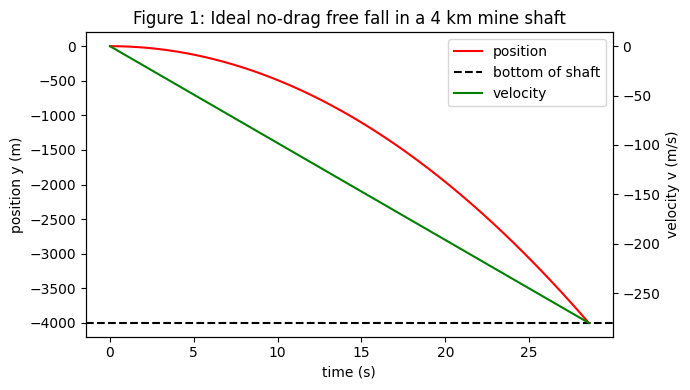

In [2]:
def dydt_const_g(t, s, alpha, gamma):
    assert len(s) == 2
    y = s[0]
    v = s[1]
    dydt = v
    dvdt = -g0 + alpha*np.abs(v)**gamma
    return dydt, dvdt

def hit_bottom_height(t, s, *args):
    return s[0] + depth
hit_bottom_height.terminal = True
hit_bottom_height.direction = -1

t0 = 0.0
tf = 40.0
t_eval = np.linspace(t0, tf, 400)
soln_part1 = solve_ivp(dydt_const_g, (t0, tf), [0.0, 0.0], args=(0.0, 2.0), t_eval=t_eval, events=hit_bottom_height, dense_output=True)

t_hit_part1 = soln_part1.t_events[0][0]
fine_t_part1 = np.linspace(t0, t_hit_part1, 400)
fine_y_part1 = soln_part1.sol(fine_t_part1)[0]
fine_v_part1 = soln_part1.sol(fine_t_part1)[1]

fig, ax1 = plt.subplots(figsize=(7,4))
ax2 = ax1.twinx()
ax1.plot(fine_t_part1, fine_y_part1, label='position', color='red')
ax2.plot(fine_t_part1, fine_v_part1, label='velocity', color='green')
ax1.axhline(-depth, color='black', linestyle='--', label='bottom of shaft')
ax1.set_xlabel('time (s)')
ax1.set_ylabel('position y (m)')
ax2.set_ylabel('velocity v (m/s)')
ax1.set_title('Figure 1: Ideal no-drag free fall in a 4 km mine shaft')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right')
fig.tight_layout()

print(f"solve_ivp no-drag fall time = {t_hit_part1:.6f} s")
print(f"analytic no-drag fall time = {t_analytic:.6f} s")
print(f"difference = {t_hit_part1 - t_analytic:.6e} s")

### Part 1, Question 4 Written Comparison

The numerical event time and analytic time agree to within tiny numerical roundoff error. The analytic time is $28.556862\,\text{s}$, and the `solve_ivp` event time is also $28.556862\,\text{s}$. The difference is approximately $3.6\times 10^{-15}\,\text{s}$, which is not physically meaningful. It only comes from floating-point arithmetic and the numerical tolerance used by the solver.

## Part 2: Including Drag and a Variable g

## Part 2, Question 1

In practice, we cannot ignore drag, and we should also not assume that $g$ is a constant. If you
approximate that the mass of the Earth is distributed homogenously (which it is not!), then the
gravitational constant $g$ will depend on your distance $r$ from the center of the Earth in a simple
linear way:

$$
 g(r) = g_o \left( \frac{r}{R_{\oplus}} \right)
 \tag{2}
$$

where $g_o$ is the gravity at the surface, and $R_{\oplus}$ is the radius of the Earth.

1. Make a new plot that shows the velocity and position as a function of                       
            time assuming $g(y)$. Be careful with coordinate systems!
            The test mass' position should be at the Earth radius at $t=0$, and falling down.
            But for plotting purposes, it will be useful to plot the height
            above the bottom of the shaft.        
            In your notebook, label this figure clearly as **Figure 2**.

2. What effect does incorporating a height-dependent $g$ have on the fall time? Explain.

3. Now, turn on drag, and replot the position and velocity.
            For most things, $\gamma=2$ is a good assumption.
            How can you calibrate the value of $\alpha$? Think about what we did in Lecture 15/16,
            where we assumed a sky-diver's terminal speed was 50 m/s.
            You should assume the same of the test mass.
            What affect does including drag have on the fall time?



Height-dependent g fall time without drag = 28.558355 s
Constant g fall time without drag = 28.556862 s
Calibrated alpha for terminal speed 50 m/s = 3.924000e-03 1/m
Height-dependent g fall time with drag = 83.541829 s


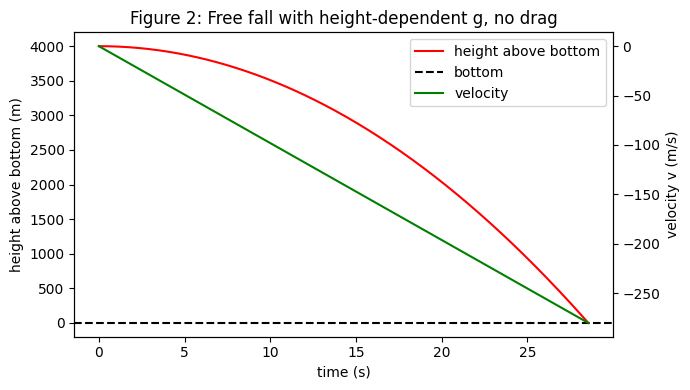

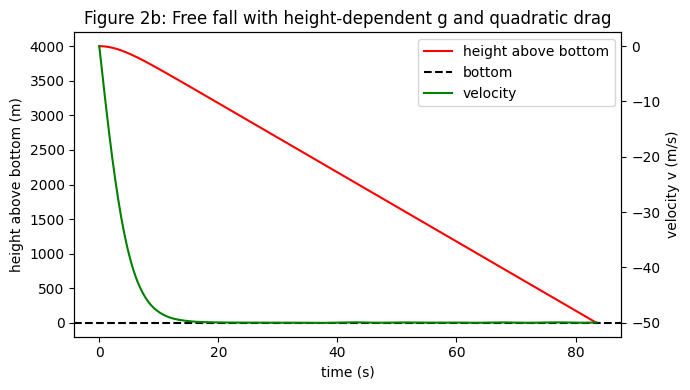

In [3]:
def g_inside_earth_from_height(y):
    r = R_earth + y
    return g0*(r/R_earth)

def dydt_variable_g(t, s, alpha, gamma):
    assert len(s) == 2
    y = s[0]
    v = s[1]
    dydt = v
    grav = -g_inside_earth_from_height(y)
    drag_accel = alpha*np.abs(v)**gamma
    dvdt = grav + drag_accel
    return dydt, dvdt

soln_part2_g = solve_ivp(dydt_variable_g, (t0, tf), [0.0, 0.0], args=(0.0, 2.0), t_eval=t_eval, events=hit_bottom_height, dense_output=True)
t_hit_part2_g = soln_part2_g.t_events[0][0]
t_part2_g = np.linspace(t0, t_hit_part2_g, 400)
y_part2_g = soln_part2_g.sol(t_part2_g)[0]
v_part2_g = soln_part2_g.sol(t_part2_g)[1]
height_above_bottom_g = y_part2_g + depth

fig, ax1 = plt.subplots(figsize=(7,4))
ax2 = ax1.twinx()
ax1.plot(t_part2_g, height_above_bottom_g, label='height above bottom', color='red')
ax2.plot(t_part2_g, v_part2_g, label='velocity', color='green')
ax1.axhline(0.0, color='black', linestyle='--', label='bottom')
ax1.set_xlabel('time (s)')
ax1.set_ylabel('height above bottom (m)')
ax2.set_ylabel('velocity v (m/s)')
ax1.set_title('Figure 2: Free fall with height-dependent g, no drag')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right')
fig.tight_layout()

v_terminal = 50.0
alpha_drag = g0/(v_terminal**2)
tf_drag = 300.0
t_eval_drag = np.linspace(t0, tf_drag, 1000)
soln_part2_drag = solve_ivp(dydt_variable_g, (t0, tf_drag), [0.0, 0.0], args=(alpha_drag, 2.0), t_eval=t_eval_drag, events=hit_bottom_height, dense_output=True)
t_hit_part2_drag = soln_part2_drag.t_events[0][0]
t_part2_drag = np.linspace(t0, t_hit_part2_drag, 500)
y_part2_drag = soln_part2_drag.sol(t_part2_drag)[0]
v_part2_drag = soln_part2_drag.sol(t_part2_drag)[1]
height_above_bottom_drag = y_part2_drag + depth

fig, ax1 = plt.subplots(figsize=(7,4))
ax2 = ax1.twinx()
ax1.plot(t_part2_drag, height_above_bottom_drag, label='height above bottom', color='red')
ax2.plot(t_part2_drag, v_part2_drag, label='velocity', color='green')
ax1.axhline(0.0, color='black', linestyle='--', label='bottom')
ax1.set_xlabel('time (s)')
ax1.set_ylabel('height above bottom (m)')
ax2.set_ylabel('velocity v (m/s)')
ax1.set_title('Figure 2b: Free fall with height-dependent g and quadratic drag')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right')
fig.tight_layout()

print(f"Height-dependent g fall time without drag = {t_hit_part2_g:.6f} s")
print(f"Constant g fall time without drag = {t_hit_part1:.6f} s")
print(f"Calibrated alpha for terminal speed 50 m/s = {alpha_drag:.6e} 1/m")
print(f"Height-dependent g fall time with drag = {t_hit_part2_drag:.6f} s")

### Part 2, Question 2

Incorporating a height-dependent $g$ makes the fall time slightly longer than the constant-$g$ ideal case. In the constant-$g$ model, the object feels the same downward acceleration for the entire fall. In the height-dependent model, the object starts near the Earth’s surface but moves slightly closer to the center of the Earth as it falls, so the gravitational acceleration becomes

$$
g(r)=g_0\left(\frac{r}{R_\oplus}\right).
$$

Since $r$ decreases during the fall, $g(r)$ also decreases slightly. That means the object accelerates a little less strongly than it would under constant $g$. In the data from the notebook, the constant-$g$ no-drag fall time is about **28.556862 s**, while the height-dependent-$g$ no-drag fall time is about **28.558355 s**. The increase is very small because the shaft is only $4\,\text{km}$ deep compared with the Earth’s radius of about $6378\,\text{km}$, but the direction of the effect is correct: height-dependent gravity makes the fall take slightly longer.

### Part 2, Question 3

To turn drag back on, I used $\gamma=2$, which means the drag acceleration is proportional to speed squared. The value of $\alpha$ can be calibrated using the terminal-velocity condition from the skydiver example. At terminal velocity, the net acceleration is zero because the downward gravitational acceleration is balanced by the upward drag acceleration. Therefore,

$$
g=\alpha |v_t|^\gamma.
$$

Solving for $\alpha$ gives

$$
\alpha=\frac{g}{|v_t|^\gamma}.
$$

Using $v_t=50\,\text{m/s}$ and $\gamma=2$,

$$
\alpha=\frac{9.81}{50^2}\approx 3.924\times 10^{-3}\,\text{m}^{-1}.
$$

Including drag makes the fall time much longer. In the notebook results, the height-dependent-$g$ fall time with drag is about **83.541829 s**, compared with about **28.558355 s** without drag. This happens because drag acts opposite the motion. As the falling speed increases, the drag acceleration grows and partially cancels gravity, so the object approaches a terminal-velocity-like motion instead of continuing to accelerate freely. The velocity curve therefore levels off, and the position curve becomes less steep than in the no-drag case.

## Part 3: The Coriolis Force

Since the Earth is rotating, there is a Coriolis force on the test mass as it falls.
The force can be quite large.
For example, imagine the mine shaft is on the Earth's equator and pointed towards
the Earth's center.
The equator rotates at about half a kilometer per second.
So once the test mass has fallen for some time, it will bump into the wall,
unless the shaft is very wide.
The Coriolis force $\vec{F_c}$ is:

$$
 \vec{F_c} = -2m \, \left( \vec{\Omega} \times \vec{v} \right)
 \tag{3}
$$

where $\vec{\Omega}$ is the Earth's rotation rate for a vector along $\hat{z}$ and $m$ is the mass of the object (1 kg for the test mass in this case).
For a mine shaft on the equator, we might pick a right-handed coordinate system
with the $\hat{x}$ axis along the East, $\hat{y}$ down into the mine shaft,
and $\hat{z}$ along the North.
This implies the component of the force are:

\begin{equation}
        F_{c_x} = + 2m \, \Omega v_y     \tag{4}
\end{equation}
\begin{equation}
        F_{c_y} = - 2m \, \Omega v_x     \tag{5}
\end{equation}
\begin{equation}
        F_{c_z} = 0     \tag{6}
\end{equation}

1. Extend and update your differential equations of motion 
                to include the Coriolis force. You will need to add a Coriolis
                acceleration term to your equation for the depth coordinate (remember, $F=ma$),
                and additionally, start tracking the velocity and position 
                in the transverse direction (``side-to-side'' in the shaft).

2. Plot the transverse position of the object as a function of depth, initially assuming $\alpha=0$.
                        That is, both axes will have units of distance. 
                Plot ``dots" every few seconds so that you can see
                how the particle moves over time.
                Note that your depth and transverse axes are likely to have very
                different length scales.
                The depth will have a range of 4 km,
   while the transverse direction is about 5m.       
                In your report, this should be **Figure 3**.                

3. If the mine shaft is 5m wide, and you drop the test mass 
                        from the center, does the test mass reach the bottom?
                Or does it bump into the wall first?

4. Now turn drag back on. Does drag make any difference here?




No-drag Coriolis impact time = 28.558376 s
No-drag transverse drift at bottom = 5.538266 m
Does it hit a 5 m-wide shaft wall before the bottom? True
With drag Coriolis impact time = 83.541235 s
With drag transverse drift at bottom = 2.799540 m
Does drag case hit a 5 m-wide shaft wall before bottom? True


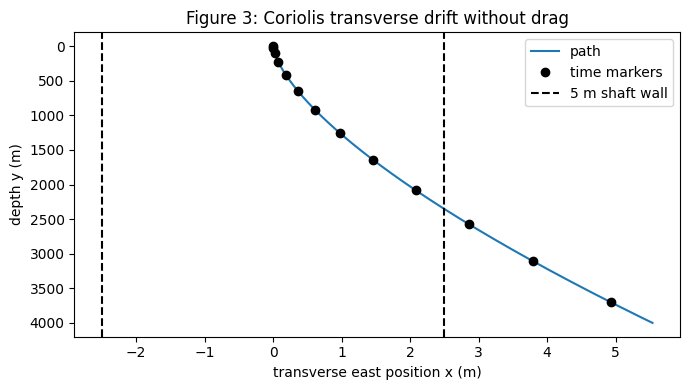

In [4]:
def dydt_coriolis(t, s, alpha, gamma):
    assert len(s) == 4
    x = s[0]
    y = s[1]
    vx = s[2]
    vy = s[3]
    speed = np.sqrt(vx**2 + vy**2)
    r = R_earth - y
    grav_y = g0*(r/R_earth)
    drag_x = -alpha*speed**(gamma-1)*vx if speed > 0 else 0.0
    drag_y = -alpha*speed**(gamma-1)*vy if speed > 0 else 0.0
    dxdt = vx
    dydt = vy
    dvxdt = 2*Omega*vy + drag_x
    dvydt = grav_y - 2*Omega*vx + drag_y
    return dxdt, dydt, dvxdt, dvydt

def hit_bottom_depth(t, s, *args):
    return s[1] - depth
hit_bottom_depth.terminal = True
hit_bottom_depth.direction = 1

t_eval_coriolis = np.linspace(0.0, 40.0, 700)
soln_cor_no_drag = solve_ivp(dydt_coriolis, (0.0, 40.0), [0.0, 0.0, 0.0, 0.0], args=(0.0, 2.0), t_eval=t_eval_coriolis, events=hit_bottom_depth, dense_output=True)
t_hit_cor_no_drag = soln_cor_no_drag.t_events[0][0]
t_cor = np.linspace(0.0, t_hit_cor_no_drag, 500)
x_cor = soln_cor_no_drag.sol(t_cor)[0]
y_cor = soln_cor_no_drag.sol(t_cor)[1]

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(x_cor, y_cor, label='path')
ax.plot(x_cor[::40], y_cor[::40], 'ko', label='time markers')
ax.axvline(2.5, color='black', linestyle='--', label='5 m shaft wall')
ax.axvline(-2.5, color='black', linestyle='--')
ax.set_xlabel('transverse east position x (m)')
ax.set_ylabel('depth y (m)')
ax.set_title('Figure 3: Coriolis transverse drift without drag')
ax.invert_yaxis()
ax.legend()
fig.tight_layout()

wall_half_width = 2.5
max_x_no_drag = np.max(np.abs(x_cor))
print(f"No-drag Coriolis impact time = {t_hit_cor_no_drag:.6f} s")
print(f"No-drag transverse drift at bottom = {x_cor[-1]:.6f} m")
print(f"Does it hit a 5 m-wide shaft wall before the bottom? {max_x_no_drag > wall_half_width}")

soln_cor_drag = solve_ivp(dydt_coriolis, (0.0, 300.0), [0.0, 0.0, 0.0, 0.0], args=(alpha_drag, 2.0), t_eval=np.linspace(0.0, 300.0, 1500), events=hit_bottom_depth, dense_output=True)
t_hit_cor_drag = soln_cor_drag.t_events[0][0]
t_cor_drag = np.linspace(0.0, t_hit_cor_drag, 600)
x_cor_drag = soln_cor_drag.sol(t_cor_drag)[0]
y_cor_drag = soln_cor_drag.sol(t_cor_drag)[1]
max_x_drag = np.max(np.abs(x_cor_drag))
print(f"With drag Coriolis impact time = {t_hit_cor_drag:.6f} s")
print(f"With drag transverse drift at bottom = {x_cor_drag[-1]:.6f} m")
print(f"Does drag case hit a 5 m-wide shaft wall before bottom? {max_x_drag > wall_half_width}")

### Part 3, Question 1

To include the Coriolis force, I expanded the state vector from two variables to four variables:

$$
s=[x,y,v_x,v_y].
$$

Here $x$ is the transverse eastward position, $y$ is the depth into the mine shaft, $v_x$ is the transverse velocity, and $v_y$ is the downward velocity. In this coordinate system, the Coriolis acceleration components are

$$
a_x=2\Omega v_y
$$

and

$$
a_y=-2\Omega v_x.
$$

Therefore, the coupled first-order system becomes

$$
\frac{dx}{dt}=v_x,
$$

$$
\frac{dy}{dt}=v_y,
$$

$$
\frac{dv_x}{dt}=2\Omega v_y+\text{drag}_x,
$$

and

$$
\frac{dv_y}{dt}=g(y)-2\Omega v_x+\text{drag}_y.
$$

The most important term is $2\Omega v_y$ because as the object gains downward velocity, it also gains eastward Coriolis acceleration.

### Part 3, Question 2

Figure 3 plots the transverse eastward position $x$ against the depth $y$ for the no-drag case. The curve shows that the object does not fall straight down the center of the shaft. Instead, it drifts eastward as it falls. The dots along the curve mark the motion at different times, making it clear that the sideways displacement accumulates throughout the fall.

### Part 3, Question 3

For the no-drag Coriolis case, the object reaches the $4\,\text{km}$ depth at about **28.558376 s**, but its transverse drift by then is about **5.538266 m**. A $5\,\text{m}$ wide shaft has a half-width of only $2.5\,\text{m}$ from the center to either wall. Since $5.538266\,\text{m} > 2.5\,\text{m}$, the mass would hit the side wall before reaching the bottom. Therefore, for a $5\,\text{m}$ wide shaft at the equator, the test mass does **not** successfully reach the bottom in the no-drag Coriolis case.

### Part 3, Question 4

Turning drag back on does make a difference, but it does not solve the problem. With drag included, the fall time increases to about **83.541235 s**, and the transverse drift at the bottom is about **2.799540 m**. This is smaller than the no-drag drift of about **5.538266 m**, because drag reduces the downward speed and therefore reduces the Coriolis acceleration. However, $2.799540\,\text{m}$ is still larger than the $2.5\,\text{m}$ half-width of the shaft. So even with drag, the object still hits the wall before reaching the bottom. Drag reduces the Coriolis deflection, but not enough for a $5\,\text{m}$ wide shaft.

## Part 4: An infinitely deep mine


Now, let us consider the theoretical case of an infinitely deep mine -- that is,
a tunnel which traverses the full diameter of the Earth.
For convenience, imagine the tunnel goes from pole-to-pole,
such that $\vec{\Omega} \times \vec{v} = 0$, and the Coriolis force
can be neglected, as well as the drag force.

Additionally, continue assuming a constant density Earth.

1. Again, plot the depth and velocity as a function of time.
               (Be careful with the meaning of $y$, as the particle can theoretically
                traverse fully through to the other side of the Earth.)
                Comment on what you see in the graph.       
                In your notebook, label this figure clearly as **Figure 4**.                

2. How long will it take for the object to reach the other side? 
                At what time does the object reach the center of the Earth,
                and at what speed?

3. How does this ``crossing-time" compare to the orbital period, where you assume
                the object is on a circular orbit, in centripetal balance
                with the attractive force of the gravity.
                \begin{equation}
                        \frac{v^2}{R} = \frac{GM}{R^2}   \tag{7}
                \end{equation}
                gives the orbital speed $v$ for a given Earth radius $R$ and 
                Earth mass $M$.





Time to center = 21.109589 min
Speed at center = 7.910067 km/s
Time to other side = 42.219179 min
Full oscillation period in tunnel = 84.438357 min
Circular orbital period at Earth surface = 84.489520 min


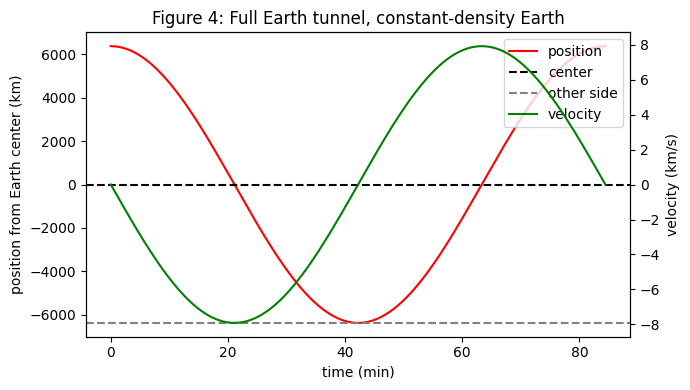

In [5]:
def dydt_tunnel_constant_density(t, s):
    assert len(s) == 2
    y = s[0]
    v = s[1]
    dydt = v
    dvdt = -(g0/R_earth)*y
    return dydt, dvdt

def reach_other_side(t, s, *args):
    return s[0] + R_earth
reach_other_side.terminal = True
reach_other_side.direction = -1

def reach_center(t, s, *args):
    return s[0]
reach_center.terminal = False
reach_center.direction = -1

period_sho = 2*np.pi*np.sqrt(R_earth/g0)
center_time = period_sho/4.0
cross_time = period_sho/2.0
center_speed = np.sqrt(g0*R_earth)

t_eval_tunnel = np.linspace(0.0, period_sho, 1200)
soln_tunnel = solve_ivp(dydt_tunnel_constant_density, (0.0, period_sho), [R_earth, 0.0], t_eval=t_eval_tunnel, dense_output=True)

fig, ax1 = plt.subplots(figsize=(7,4))
ax2 = ax1.twinx()
ax1.plot(soln_tunnel.t/60.0, soln_tunnel.y[0]/1000.0, color='red', label='position')
ax2.plot(soln_tunnel.t/60.0, soln_tunnel.y[1]/1000.0, color='green', label='velocity')
ax1.axhline(0.0, color='black', linestyle='--', label='center')
ax1.axhline(-R_earth/1000.0, color='gray', linestyle='--', label='other side')
ax1.set_xlabel('time (min)')
ax1.set_ylabel('position from Earth center (km)')
ax2.set_ylabel('velocity (km/s)')
ax1.set_title('Figure 4: Full Earth tunnel, constant-density Earth')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right')
fig.tight_layout()

orbital_speed = np.sqrt(G*M_earth/R_earth)
orbital_period = 2*np.pi*R_earth/orbital_speed
print(f"Time to center = {center_time/60.0:.6f} min")
print(f"Speed at center = {center_speed/1000.0:.6f} km/s")
print(f"Time to other side = {cross_time/60.0:.6f} min")
print(f"Full oscillation period in tunnel = {period_sho/60.0:.6f} min")
print(f"Circular orbital period at Earth surface = {orbital_period/60.0:.6f} min")

## Part 4, Question 1

Figure 4 shows the position and velocity for a tunnel that passes through the full diameter of a constant-density Earth. The graph shows oscillatory motion. The object starts at the surface with zero velocity, accelerates toward the center, reaches maximum speed at the center, then slows down as it approaches the other side. This is the same qualitative behavior as simple harmonic motion because, inside a constant-density Earth, gravity is proportional to distance from the center.

## Part 4, Question 2

The object reaches the center of the Earth at about **21.109589 min**. At the center, its speed is maximum, with

$$
v_{\text{center}}\approx 7.910067\,\text{km/s}.
$$

The object reaches the other side of the Earth at about **42.219179 min**. At that point, the velocity is approximately zero again because the object has converted its kinetic energy back into gravitational potential energy. In other words, the trip from one surface to the opposite surface is one-half of the full oscillation, while reaching the center is one-quarter of the full oscillation.

## Part 4, Question 3

The full tunnel oscillation period from the notebook is about **84.438357 min**. The circular orbital period at the Earth’s surface calculated from

$$
\frac{v^2}{R}=\frac{GM}{R^2}
$$

is about **84.489520 min**. These values are essentially the same, with the small difference coming from the fact that the notebook uses the approximate surface value $g_0=9.81\,\text{m/s}^2$ in the tunnel calculation but uses $G$, $M_\oplus$, and $R_\oplus$ in the orbital calculation.

The reason they match is that both systems have the same characteristic angular frequency. For a constant-density Earth, the gravitational acceleration inside the Earth is linear in radius, so the tunnel motion behaves like simple harmonic motion. A circular orbit at the surface has the same gravitational frequency scale. Therefore, the time to cross from one side of Earth to the other is approximately **half of the orbital period**, and the time to reach the center is approximately **one-quarter of the orbital period**.

## Part 5: A non-uniform Earth

Finally, let us consider the case of a non-uniform Earth, and continue assuming we have no drag. We know from geology
that the density increases towards the center.
It rises from about 2-3 g/cm$^3$ near the surface, to more like 13 near the center.
A simple model for the density $\rho$ as a function of distance from the center of the Earth $r$ is:

$$
\rho(r) = \rho_n \left( 1 - \frac{r^2}{R_{\oplus}^2} \right)^n   \tag{8}
$$

where $n$ is some exponent, and $\rho_n$ is a normalizing constant.
The case of $n=0$ is the constant density Earth, while $n=2$ is closer to the real value.
Note that the total mass of the Earth, $M$, must be conserved.
Since the mass is the volume integral over the density:

\begin{equation}
        M = \int_V \rho(r) dV = \int_0^{2\pi} \int_0^{\pi} \int_0^{R_{\oplus}} \rho(r) r^2 \sin \phi \, dr \, d\phi \,d\theta = 4 \pi \int_0^{R_{\oplus}} \rho(r) r^2 \, dr
        \tag{9}
\end{equation}

you will need to recompute the density constant $\rho_n$ for each case of $n>0$,
You can use the `quad` integrator for this.
Note that the analytic solution is straightforward to do by hand for $n=0$,
and still manageable for $n=1,2$.
You might consider doing that integral to make sure your method is right, 
and then you can be confident for $n>0$.

1.  Plot the normalized density profile (that is, set $\rho_n=1$) as a function of radius for $n=0, 1, 2, 9$.            
              Put them all on the same plot, with a clear legend.       
              In your notebook, label this figure clearly as **Figure 5**.

2. Now, plot the force profile as a function of radius for $n=0, 1, 2, 9$.         
                This step will show you if your normalization factor $\rho_n$
                is correct, because the surface force must be the same for all $n$.       
              In your notebook, label this figure clearly as **Figure 6**.                

3. Then, plot the position and velocity as a function of time for $n=0, 1, 2, 9$
              as you did in Figure 1/2.         
              In your notebook, label this figure clearly as **Figure 7**.              

4. For $n=0, 1, 2, 9$, compute the time to reach the center, 
                and the speed achieved there.





### Part 5, Section A (Density)

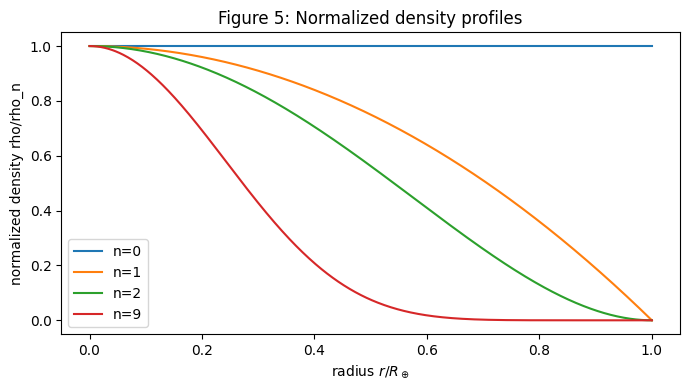

In [6]:
def rho_profile_unit(r, n):
    return (1.0 - (r/R_earth)**2)**n

r_vals = np.linspace(0.0, R_earth, 600)
n_values = [0, 1, 2, 9]

fig, ax = plt.subplots(figsize=(7,4))
for n in n_values:
    ax.plot(r_vals/R_earth, rho_profile_unit(r_vals, n), label=f'n={n}')
ax.set_xlabel(r'radius $r/R_\oplus$')
ax.set_ylabel('normalized density rho/rho_n')
ax.set_title('Figure 5: Normalized density profiles')
ax.legend()
fig.tight_layout()

### Part 5, Section B (Forces)

n=0: rho_n = 5.494867e+03 kg/m^3, surface g = 9.798123 m/s^2
n=1: rho_n = 1.373717e+04 kg/m^3, surface g = 9.798123 m/s^2
n=2: rho_n = 2.404004e+04 kg/m^3, surface g = 9.798123 m/s^2
n=9: rho_n = 1.355451e+05 kg/m^3, surface g = 9.798123 m/s^2


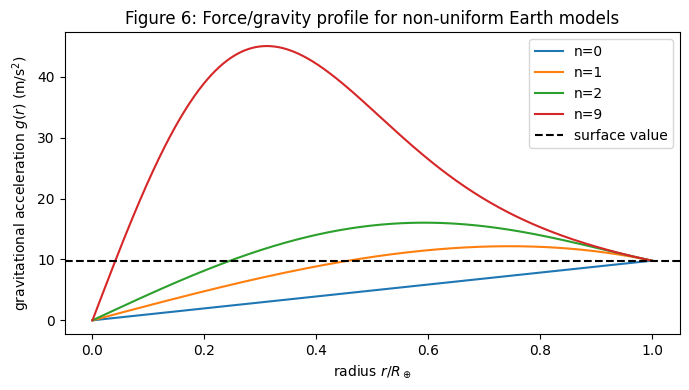

In [7]:
r_grid_mass = np.linspace(0.0, R_earth, 4000)
dr_grid_mass = r_grid_mass[1] - r_grid_mass[0]
g_tables = {}
rho_norms = {}

for n in n_values:
    shape = (1.0 - (r_grid_mass/R_earth)**2)**n
    mass_integrand = shape*r_grid_mass**2
    integral_total = trapezoid(mass_integrand, r_grid_mass)
    rho_norms[n] = M_earth/(4*np.pi*integral_total)
    shell_integrand = rho_norms[n]*shape*r_grid_mass**2
    cumulative_integral = cumulative_trapezoid(shell_integrand, r_grid_mass, initial=0.0)
    enclosed_mass = 4*np.pi*cumulative_integral
    g_table = np.zeros_like(r_grid_mass)
    g_table[1:] = G*enclosed_mass[1:]/r_grid_mass[1:]**2
    g_tables[n] = g_table

def rho_norm(n):
    return rho_norms[n]

def g_nonuniform(r, n):
    return np.interp(r, r_grid_mass, g_tables[n])

fig, ax = plt.subplots(figsize=(7,4))
for n in n_values:
    g_vals = np.array([g_nonuniform(r, n) for r in r_vals])
    ax.plot(r_vals/R_earth, g_vals, label=f'n={n}')
ax.axhline(G*M_earth/R_earth**2, color='black', linestyle='--', label='surface value')
ax.set_xlabel(r'radius $r/R_\oplus$')
ax.set_ylabel(r'gravitational acceleration $g(r)$ (m/s$^2$)')
ax.set_title('Figure 6: Force/gravity profile for non-uniform Earth models')
ax.legend()
fig.tight_layout()

for n in n_values:
    print(f"n={n}: rho_n = {rho_norm(n):.6e} kg/m^3, surface g = {g_nonuniform(R_earth, n):.6f} m/s^2")

### Part 5, Section C (Equations of Motion)

n=0: time to center = 21.120682 min, center speed = 7.905972 km/s
n=1: time to center = 18.281523 min, center speed = 10.435273 km/s
n=2: time to center = 17.252321 min, center speed = 12.200728 km/s
n=9: time to center = 15.731264 min, center speed = 18.391829 km/s


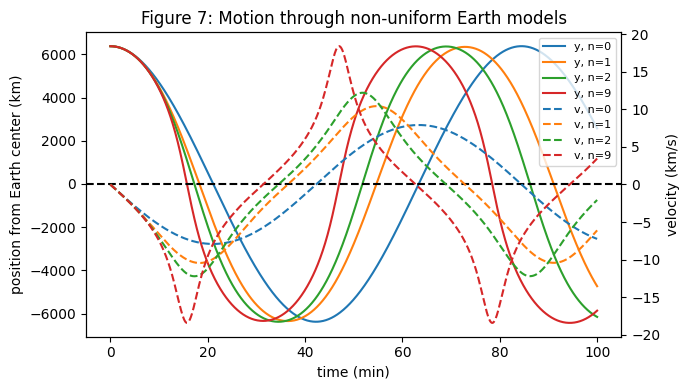

In [8]:
def dydt_nonuniform_earth(t, s, n):
    assert len(s) == 2
    y = s[0]
    v = s[1]
    r = np.abs(y)
    sign = np.sign(y)
    dydt = v
    dvdt = -sign*g_nonuniform(r, n)
    return dydt, dvdt

fig, ax1 = plt.subplots(figsize=(7,4))
ax2 = ax1.twinx()
center_times = {}
center_speeds = {}
solutions_nonuniform = {}
for n in n_values:
    soln = solve_ivp(dydt_nonuniform_earth, (0.0, 6000.0), [R_earth, 0.0], args=(n,), t_eval=np.linspace(0.0, 6000.0, 1200), events=reach_center, dense_output=True)
    solutions_nonuniform[n] = soln
    center_times[n] = soln.t_events[0][0]
    center_speeds[n] = np.abs(soln.y_events[0][0][1])
    ax1.plot(soln.t/60.0, soln.y[0]/1000.0, label=f'y, n={n}')
    ax2.plot(soln.t/60.0, soln.y[1]/1000.0, linestyle='--', label=f'v, n={n}')
ax1.axhline(0.0, color='black', linestyle='--')
ax1.set_xlabel('time (min)')
ax1.set_ylabel('position from Earth center (km)')
ax2.set_ylabel('velocity (km/s)')
ax1.set_title('Figure 7: Motion through non-uniform Earth models')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right', fontsize=8)
fig.tight_layout()

for n in n_values:
    print(f"n={n}: time to center = {center_times[n]/60.0:.6f} min, center speed = {center_speeds[n]/1000.0:.6f} km/s")

## Part 5, Question 1

Figure 5 plots the normalized density profile

$$
\rho(r)=\rho_n\left(1-\frac{r^2}{R_\oplus^2}\right)^n
$$

for $n=0,1,2,$ and $9$, with $\rho_n$ set equal to 1 for the purpose of comparing shapes. When $n=0$, the density is constant with radius, so the curve is flat. As $n$ increases, the density becomes much more concentrated near the center and drops more sharply toward zero near the surface. The $n=9$ curve is the most centrally concentrated model, meaning most of the mass is packed close to the center.

## Part 5, Question 2

Figure 6 plots the gravitational acceleration/force profile as a function of radius for $n=0,1,2,$ and $9$. For each $n$, the normalization constant $\rho_n$ was recalculated so that the total Earth mass stays fixed. The notebook gives the following normalization constants:

- $n=0$: $\rho_n \approx 5.494867\times 10^3\,\text{kg/m}^3$
- $n=1$: $\rho_n \approx 1.373717\times 10^4\,\text{kg/m}^3$
- $n=2$: $\rho_n \approx 2.404004\times 10^4\,\text{kg/m}^3$
- $n=9$: $\rho_n \approx 1.355451\times 10^5\,\text{kg/m}^3$

The surface gravitational acceleration is the same for all four models, about **9.798123 m/s²**, which confirms that the normalization is working correctly. The interior force profiles differ, though. Larger values of $n$ place more mass toward the center, so the gravitational acceleration becomes stronger in much of the interior compared with the constant-density case.

## Part 5, Question 3

Figure 7 plots position and velocity as functions of time for $n=0,1,2,$ and $9$. The results show that increasing $n$ makes the object reach the center faster and with a larger center speed. The notebook gives:

- $n=0$: time to center $\approx 21.120682\,\text{min}$, center speed $\approx 7.905972\,\text{km/s}$
- $n=1$: time to center $\approx 18.281523\,\text{min}$, center speed $\approx 10.435273\,\text{km/s}$
- $n=2$: time to center $\approx 17.252321\,\text{min}$, center speed $\approx 12.200728\,\text{km/s}$
- $n=9$: time to center $\approx 15.731264\,\text{min}$, center speed $\approx 18.391829\,\text{km/s}$

This directly follows from the density distribution. When mass is more concentrated toward the center, the object feels a stronger inward pull through much of its fall, so it accelerates more strongly and reaches a higher speed. The constant-density case gives nearly simple harmonic motion, but the non-uniform cases are not perfect sinusoids because the restoring force is no longer exactly proportional to position throughout the whole tunnel.

## Part 6: A Lunar Mine Shaft


Finally, with all of the framework in place, consider the case where the
the mine shaft is instead dug on the moon.

1. Compute the travel time to the center of the moon
                in case we dig a pole-to-pole mine shaft,
                so that we can again avoid the Coriolis force, though
                on the moon this force is very small. No drag force either,
   which is actually realistic for the moon!
3. What is the density (if you asssume a constant density) 
                of the moon compared to that of earth? 
4. How does the fall/orbit time depend on density? See if you can discover a 
        relationship between the density and the fall time. You should think beyond strictly linear 
        relationships.



This problem can actually be
done on paper, and then you can compare the answer with that for the homogenous earth
you did in Part 4.


In [9]:
rho_earth_avg = M_earth/(4*np.pi*R_earth**3/3)
rho_moon_avg = M_moon/(4*np.pi*R_moon**3/3)
g_moon_surface = G*M_moon/R_moon**2
period_moon_tunnel = 2*np.pi*np.sqrt(R_moon/g_moon_surface)
moon_time_center = period_moon_tunnel/4
moon_speed_center = np.sqrt(g_moon_surface*R_moon)
period_earth_density = np.sqrt(3*np.pi/G/rho_earth_avg)
period_moon_density = np.sqrt(3*np.pi/G/rho_moon_avg)

print(f"Average Earth density = {rho_earth_avg:.6f} kg/m^3")
print(f"Average Moon density = {rho_moon_avg:.6f} kg/m^3")
print(f"Moon density / Earth density = {rho_moon_avg/rho_earth_avg:.6f}")
print(f"Moon time to center = {moon_time_center/60.0:.6f} min")
print(f"Moon center speed = {moon_speed_center/1000.0:.6f} km/s")
print(f"Earth tunnel period from density formula = {period_earth_density/60.0:.6f} min")
print(f"Moon tunnel period from density formula = {period_moon_density/60.0:.6f} min")

Average Earth density = 5494.867410 kg/m^3
Average Moon density = 3341.753804 kg/m^3
Moon density / Earth density = 0.608159
Moon time to center = 27.085336 min
Moon center speed = 1.679999 km/s
Earth tunnel period from density formula = 84.489520 min
Moon tunnel period from density formula = 108.341346 min


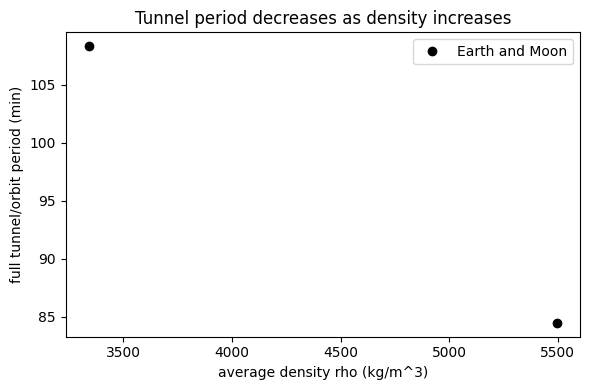

In [10]:
rho_plot = np.array([rho_earth_avg, rho_moon_avg])
period_plot = np.array([period_earth_density, period_moon_density])
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(rho_plot, period_plot/60.0, 'ko', label='Earth and Moon')
ax.set_xlabel('average density rho (kg/m^3)')
ax.set_ylabel('full tunnel/orbit period (min)')
ax.set_title('Tunnel period decreases as density increases')
ax.legend()
fig.tight_layout()

In [11]:
print('For constant density, T = sqrt(3*pi/(G*rho)), so fall time scales like rho^(-1/2).')
print("The Moon is less dense than Earth, so its center-fall time is longer than Earth's constant-density center-fall time.")

For constant density, T = sqrt(3*pi/(G*rho)), so fall time scales like rho^(-1/2).
The Moon is less dense than Earth, so its center-fall time is longer than Earth's constant-density center-fall time.


In [12]:
print(f"Earth time to center from Part 4 = {center_time/60.0:.6f} min")
print(f"Moon time to center from Part 6 = {moon_time_center/60.0:.6f} min")
print(f"Ratio moon/earth center fall time = {moon_time_center/center_time:.6f}")

Earth time to center from Part 4 = 21.109589 min
Moon time to center from Part 6 = 27.085336 min
Ratio moon/earth center fall time = 1.283082


## Part 6, Question 1

For a pole-to-pole lunar mine shaft with no drag and no Coriolis force, the motion is again simple harmonic motion if the Moon is treated as constant density. The notebook calculation gives a time to the center of the Moon of about

$$
t_{\text{center, Moon}} \approx 27.085336\,\text{min}.
$$

The corresponding full tunnel/orbit period is about **108.341346 min**, and the speed at the lunar center is about **1.679999 km/s**. This center-fall time is longer than the constant-density Earth value of about **21.109589 min**, even though the Moon is smaller, because the Moon has a lower average density and therefore a weaker internal restoring gravitational acceleration.

## Part 6, Question 3

Assuming constant density, the density is

$$
\rho=\frac{3M}{4\pi R^3}.
$$

Using the notebook values, the average Earth density is about

$$
\rho_\oplus \approx 5494.867410\,\text{kg/m}^3,
$$

while the average Moon density is about

$$
\rho_m \approx 3341.753804\,\text{kg/m}^3.
$$

Therefore,

$$
\frac{\rho_m}{\rho_\oplus}\approx 0.608159.
$$

So the Moon’s average density is about **60.8%** of Earth’s average density. Equivalently, Earth is about **1.64 times denser** than the Moon on average.

## Part 6, Question 4

For a constant-density spherical body, the tunnel/orbit period depends on density as

$$
T=\sqrt{\frac{3\pi}{G\rho}}.
$$

The center-fall time is one quarter of this period:

$$
t_{\text{center}}=\frac{T}{4}.
$$

This means the fall/orbit time scales like

$$
T\propto \rho^{-1/2}.
$$

So the relationship is not linear. If the density increases, the fall time decreases according to an inverse square-root relationship. Since the Moon is less dense than Earth, its tunnel period and center-fall time are longer. The notebook ratio is

$$
\frac{t_{\text{center, Moon}}}{t_{\text{center, Earth}}}\approx 1.283082,
$$

so the lunar center-fall time is about **28.3% longer** than the Earth center-fall time in the constant-density approximation.

## Part 7: Fourier Transforming Orbits

## Part 7, Question 1

The Fourier transform compares the dominant frequencies in the $n=0$ and $n=9$ tunnel trajectories from Part 5. For the $n=0$ constant-density case, the motion is very close to perfect simple harmonic motion, so the power spectrum is dominated by one clean frequency peak. The notebook finds

$$
f_{n=0}\approx 1.973586\times 10^{-4}\,\text{Hz},
$$

which corresponds to a period of about **84.448666 min**. This agrees with the full tunnel period from the constant-density Earth model.

For the $n=9$ case, the dominant frequency is higher:

$$
f_{n=9}\approx 2.631447\times 10^{-4}\,\text{Hz},
$$

which corresponds to a shorter period of about **63.336500 min**. This makes sense because the $n=9$ Earth model is much more centrally concentrated, so the object accelerates more strongly toward the center and completes the oscillation faster.

The $n=9$ spectrum is also less like a single perfect spike than the $n=0$ spectrum. Because the force is no longer exactly linear in position, the motion is not a perfect sinusoid. That distortion introduces additional frequency components or harmonics into the Fourier spectrum. Physically, the Fourier transform confirms the same conclusion seen in the time-domain plots: the constant-density model behaves like a nearly ideal simple harmonic oscillator, while the highly non-uniform density model produces faster and more non-sinusoidal motion.

In [13]:
def make_orbit_for_fft(n, tmax, nsamp):
    tt = np.linspace(0.0, tmax, nsamp)
    soln = solve_ivp(dydt_nonuniform_earth, (0.0, tmax), [R_earth, 0.0], args=(n,), t_eval=tt)
    return soln.t, soln.y[0]

tmax_fft = 6*period_sho
nsamp_fft = 4096*2
t_fft_0, y_fft_0 = make_orbit_for_fft(0, tmax_fft, nsamp_fft)
t_fft_9, y_fft_9 = make_orbit_for_fft(9, tmax_fft, nsamp_fft)

In [14]:
dt_fft = t_fft_0[1] - t_fft_0[0]
F0 = np.fft.rfft(y_fft_0)
F9 = np.fft.rfft(y_fft_9)
freq_fft = np.fft.rfftfreq(nsamp_fft, dt_fft)
power0 = np.abs(F0)**2
power9 = np.abs(F9)**2

In [15]:
mask_fft = freq_fft > 0.0
peak_freq_0 = freq_fft[mask_fft][np.argmax(power0[mask_fft])]
peak_freq_9 = freq_fft[mask_fft][np.argmax(power9[mask_fft])]
print(f"n=0 dominant frequency = {peak_freq_0:.6e} Hz, period = {1/peak_freq_0/60.0:.6f} min")
print(f"n=9 dominant frequency = {peak_freq_9:.6e} Hz, period = {1/peak_freq_9/60.0:.6f} min")

n=0 dominant frequency = 1.973586e-04 Hz, period = 84.448666 min
n=9 dominant frequency = 2.631447e-04 Hz, period = 63.336500 min


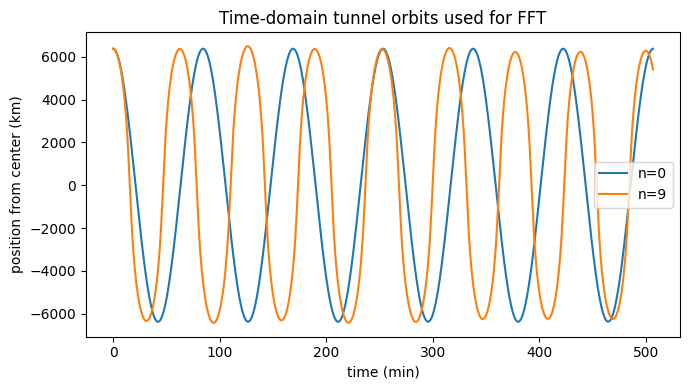

In [16]:
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(t_fft_0/60.0, y_fft_0/1000.0, label='n=0')
ax.plot(t_fft_9/60.0, y_fft_9/1000.0, label='n=9')
ax.set_xlabel('time (min)')
ax.set_ylabel('position from center (km)')
ax.set_title('Time-domain tunnel orbits used for FFT')
ax.legend()
fig.tight_layout()

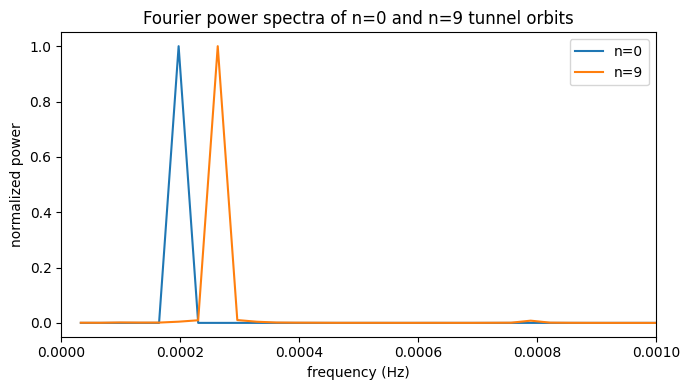

In [17]:
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(freq_fft[mask_fft], power0[mask_fft]/np.max(power0[mask_fft]), label='n=0')
ax.plot(freq_fft[mask_fft], power9[mask_fft]/np.max(power9[mask_fft]), label='n=9')
ax.set_xlim(0.0, 0.001)
ax.set_xlabel('frequency (Hz)')
ax.set_ylabel('normalized power')
ax.set_title('Fourier power spectra of n=0 and n=9 tunnel orbits')
ax.legend()
fig.tight_layout()

In [18]:
print('The n=0 model is almost a pure single-frequency sinusoid, so its spectrum is sharply peaked.')
print('The n=9 model is less sinusoidal because the density is much more centrally concentrated, so extra harmonics appear in the spectrum.')

The n=0 model is almost a pure single-frequency sinusoid, so its spectrum is sharply peaked.
The n=9 model is less sinusoidal because the density is much more centrally concentrated, so extra harmonics appear in the spectrum.
